In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# Folder containing the CSV files
csv_folder = Path(r"E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\SOK5")

# Find polarisation and PDG files separately
polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
pdg_files = sorted(csv_folder.glob("PDGs*.csv"))
if len(polarisation_files) == 0:
    raise FileNotFoundError(f"No polarisation CSV files found in {csv_folder}")

polar_df = pd.concat((pd.read_csv(csv_file) for csv_file in polarisation_files), ignore_index=True)
print(f"Loaded {len(polarisation_files)} polarisation CSV(s) and {len(pdg_files)} PDG CSV(s) from {csv_folder}")

# Filter for tissues A, G, and V
polar_df = polar_df[polar_df['Tissue'].isin(['A', 'G', 'V', 'CE'])].copy()

# Set up distinct colors for each tissue type
colors = {'A': "#222222", 'G': "#747474", 'V': "#c4c4c4"}

Loaded 3 polarisation CSV(s) and 0 PDG CSV(s) from E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\SOK5


Labeled polar plot saved successfully.


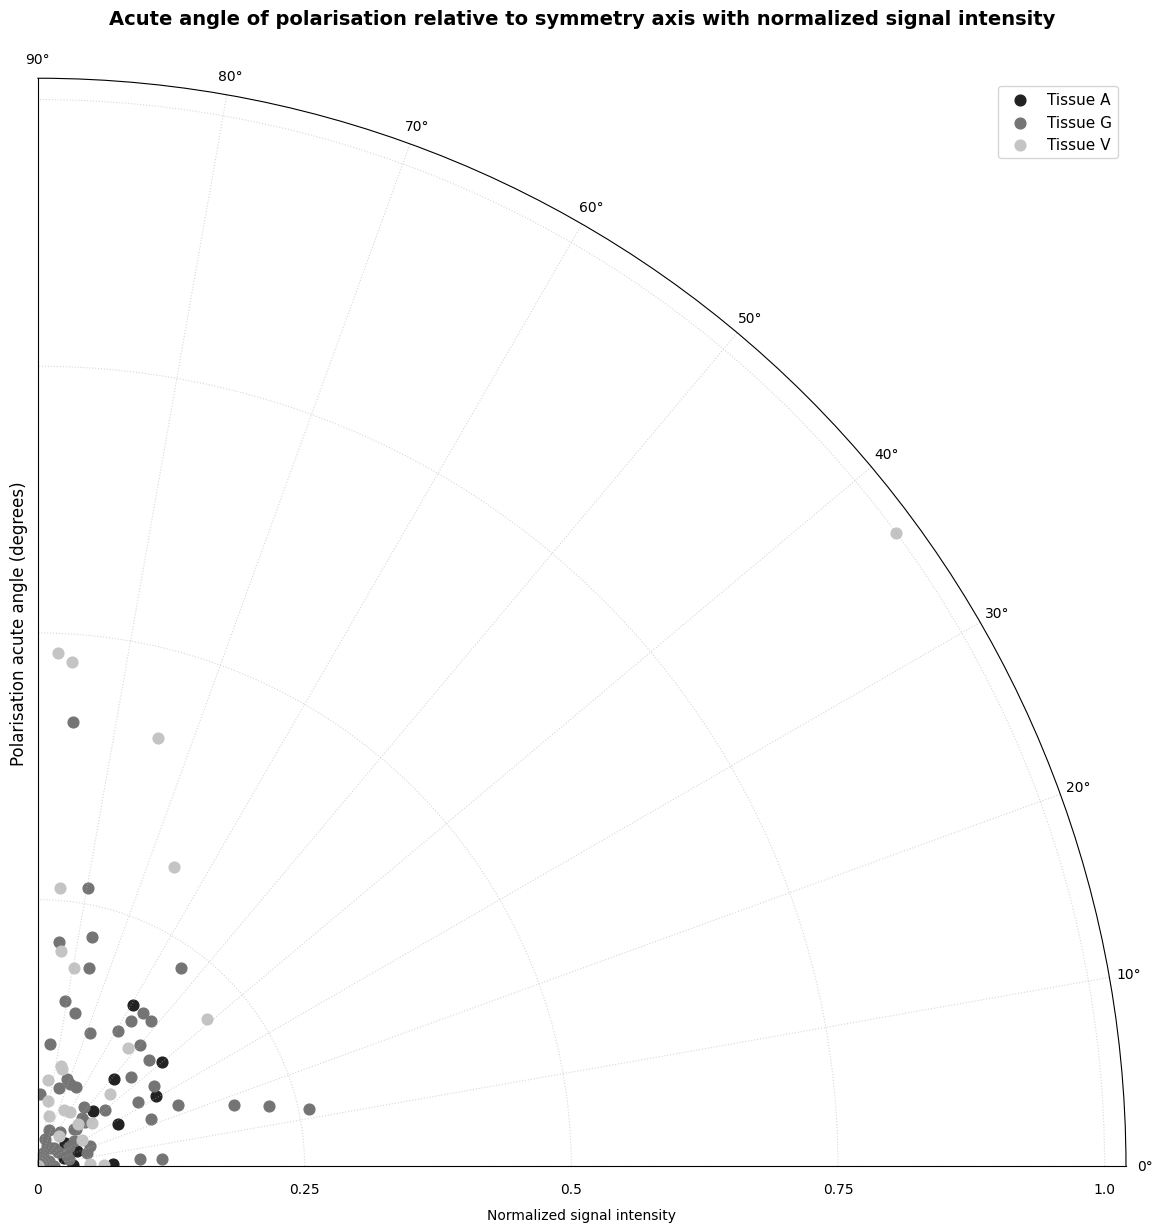

In [3]:
# Calculate the acute polarisation angle directly from raw xMax/yMax values
polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['yMax']), np.abs(polar_df['xMax'])))
polar_df['theta'] = np.radians(polar_df['deviation_degrees'])

# Normalize signal intensity to 0-1 range
polar_df['r'] = polar_df['signalMax'] / polar_df['signalMax'].max()

# Define Plot
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='polar')

# Plot each tissue
for tissue, group in polar_df.groupby('Tissue'):
    ax.scatter(group['theta'], group['r'], c=colors[tissue], label=f"Tissue {tissue}", alpha=1, s=60)
    
    # Add text labels for each point
    #for _, row in group.iterrows():
    #    ax.text(row['theta'], row['r'], str(int(row['Label'])), 
    #            fontsize=8, color=colors[tissue], ha='center', va='bottom')

# Set theta limits to 0-90 degrees (0 to pi/2)
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_theta_zero_location("E") # Horizontal line at 0 degrees
ax.set_theta_direction(1) # Counter-clockwise

# Set radial limits and labels (normalized 0-1)
ax.set_ylim(0, 1.02)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
ax.tick_params(axis='y', pad=8)

# Show normalized signal intensity on the X and Y axis labels
ax.set_xlabel('Normalized signal intensity', labelpad=25)

# Title and Labels
plt.title("Acute angle of polarisation relative to symmetry axis with normalized signal intensity", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))

plt.tight_layout()
plt.savefig("polarisation_polar_plot_labeled.svg", format='svg')
print("Labeled polar plot saved successfully.")


ax.set_ylabel('Polarisation acute angle (degrees)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

Weighted acute-angle comparison by tissue:
  A: mean=37.106°, 95% CI=(29.428, 44.292)
  G: mean=52.777°, 95% CI=(45.970, 59.142)
  V: mean=63.478°, 95% CI=(54.491, 72.318)

Pairwise weighted bootstrap comparisons:
  A vs G: delta=-15.671°, p_boot=0.0032
  A vs V: delta=-26.372°, p_boot=0.0000
  G vs V: delta=-10.701°, p_boot=0.0576
Weighted mean acute angle plot with bootstrap statistical results saved successfully.


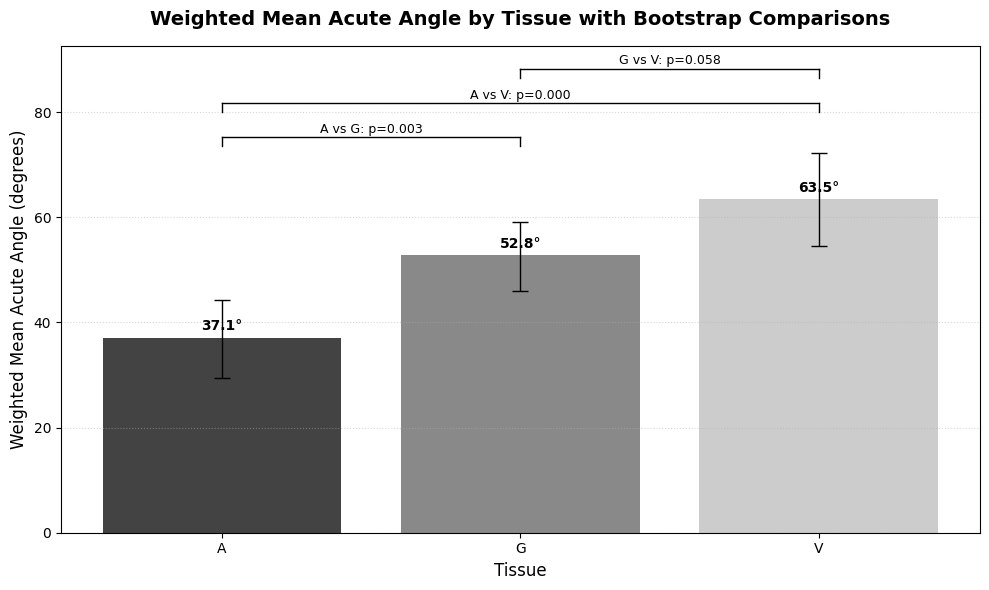

In [4]:
from itertools import combinations

# Weighted acute-angle summary per tissue
weighted_means = polar_df.groupby('Tissue').apply(
    lambda g: np.average(g['deviation_degrees'], weights=g['signalMax'])
).reset_index(name='mean_acute_angle')

# Bootstrap weighted means within each tissue
np.random.seed(0)
n_boot = 5000
bootstrap = {}
cis = {}
for tissue, group in polar_df.groupby('Tissue'):
    angles = group['deviation_degrees'].values
    weights = group['signalMax'].values
    if len(angles) == 0:
        raise ValueError(f'No data for tissue {tissue}')
    if weights.sum() <= 0:
        raise ValueError(f'Zero total weight for tissue {tissue}')

    probs = weights / weights.sum()
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(angles), size=len(angles), replace=True, p=probs)
        # Sample according to weights, then take the unweighted mean of sampled angles.
        # This yields bootstrap replicates centered on the weighted mean.
        boot_means[i] = np.mean(angles[idx])

    bootstrap[tissue] = boot_means
    cis[tissue] = np.percentile(boot_means, [2.5, 97.5])

weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis[t][0])
weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis[t][1])
weighted_means['ci_err_lo'] = np.maximum(weighted_means['mean_acute_angle'] - weighted_means['ci_lo'], 0)
weighted_means['ci_err_hi'] = np.maximum(weighted_means['ci_hi'] - weighted_means['mean_acute_angle'], 0)

# Pairwise bootstrap comparison of weighted means
pairwise_results = []
for a, b in combinations(weighted_means['Tissue'], 2):
    diffs = bootstrap[a] - bootstrap[b]
    p_boot = 2 * min(np.mean(diffs >= 0), np.mean(diffs <= 0))
    p_boot = min(p_boot, 1.0)
    a_mean = weighted_means.loc[weighted_means['Tissue'] == a, 'mean_acute_angle'].iloc[0]
    b_mean = weighted_means.loc[weighted_means['Tissue'] == b, 'mean_acute_angle'].iloc[0]
    delta = float(a_mean - b_mean)
    pairwise_results.append((a, b, p_boot, delta))

# Print weighted inference summary
print('Weighted acute-angle comparison by tissue:')
for _, row in weighted_means.iterrows():
    print(f"  {row['Tissue']}: mean={row['mean_acute_angle']:.3f}°, 95% CI=({row['ci_lo']:.3f}, {row['ci_hi']:.3f})")
print('\nPairwise weighted bootstrap comparisons:')
for a, b, p_boot, delta in pairwise_results:
    print(f'  {a} vs {b}: delta={delta:.3f}°, p_boot={p_boot:.4f}')

# Plot weighted means with bootstrap CIs and pairwise results
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(weighted_means))
bar_colors = [colors[t] for t in weighted_means['Tissue']]

ax.bar(x, weighted_means['mean_acute_angle'], color=bar_colors, alpha=0.85,
       yerr=np.vstack([weighted_means['ci_err_lo'], weighted_means['ci_err_hi']]),
       capsize=6, error_kw=dict(ecolor='black', lw=1))
ax.set_xticks(x)
ax.set_xticklabels(weighted_means['Tissue'])

for idx, row in weighted_means.iterrows():
    ax.text(idx, row['mean_acute_angle'] + 0.8,
            f"{row['mean_acute_angle']:.1f}°", ha='center', va='bottom', fontsize=10, fontweight='bold')

base = weighted_means['ci_hi'].max() * 1.04
step = weighted_means['ci_hi'].max() * 0.09
for i, (a, b, p_boot, delta) in enumerate(pairwise_results):
    left = weighted_means.index[weighted_means['Tissue'] == a][0]
    right = weighted_means.index[weighted_means['Tissue'] == b][0]
    y = base + i * step
    ax.plot([left, right], [y, y], color='black', lw=1)
    ax.plot([left, left], [y, y - step * 0.25], color='black', lw=1)
    ax.plot([right, right], [y, y - step * 0.25], color='black', lw=1)
    ax.text((left + right) / 2, y + step * 0.05,
            f"{a} vs {b}: p={p_boot:.3f}",
            ha='center', va='bottom', fontsize=9)

ax.set_title('Weighted Mean Acute Angle by Tissue with Bootstrap Comparisons', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tissue', fontsize=12)
ax.set_ylabel('Weighted Mean Acute Angle (degrees)', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('weighted_mean_acute_angle_with_stats.svg', format='svg')
print('Weighted mean acute angle plot with bootstrap statistical results saved successfully.')


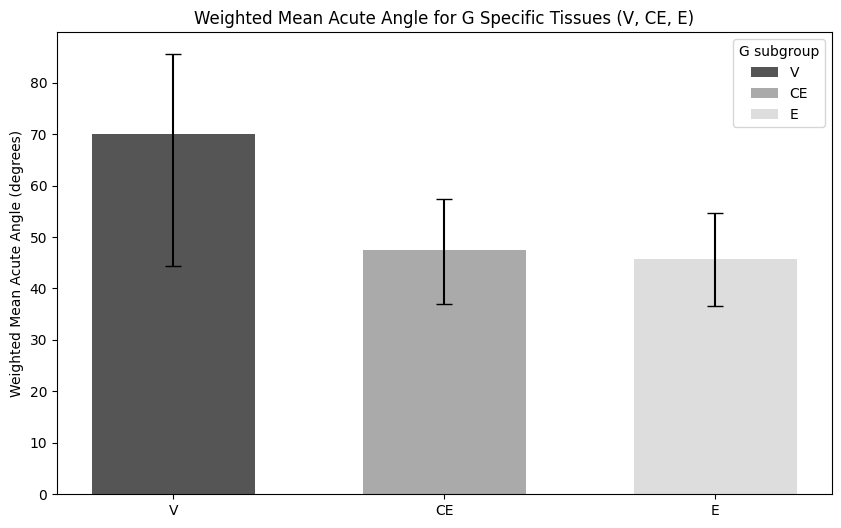

In [5]:
# Stats function
def get_weighted_stats(df, n_boot=5000):
    angles = df['deviation_degrees'].values
    weights = df['signalMax'].values
    if len(angles) == 0:
        return 0, 0, 0
    probs = weights / weights.sum() if weights.sum() > 0 else np.ones_like(weights) / len(weights)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(angles), size=len(angles), replace=True, p=probs)
        # When sampling according to weights, use the unweighted mean of the resampled angles
        # so the bootstrap replicates are centered on the weighted mean.
        boot_means[i] = np.mean(angles[idx])
    
    mean_val = np.average(angles, weights=weights) if weights.sum() > 0 else np.mean(angles)
    ci = np.percentile(boot_means, [2.5, 97.5])
    return mean_val, ci[0], ci[1]

# G sub-groups
g_subset = polar_df[polar_df['Tissue'] == 'G']
g_subgroups = ['V', 'CE', 'E']
sub_data = {}
for sg in g_subgroups:
    subset = g_subset[g_subset['Specific tissue'] == sg]
    mean, lo, hi = get_weighted_stats(subset)
    sub_data[sg] = {'mean': mean, 'lo': lo, 'hi': hi}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(g_subgroups))
sub_colors = ['#555555', '#aaaaaa', '#dddddd']

for i, sg in enumerate(g_subgroups):
    mean = sub_data[sg]['mean']
    lo = sub_data[sg]['lo']
    hi = sub_data[sg]['hi']

    # Ensure error values are non-negative
    e_low = max(mean - lo, 0)
    e_high = max(hi - mean, 0)

    ax.bar(x_pos[i], mean,
           color=sub_colors[i],
           yerr=np.array([[e_low], [e_high]]),
           capsize=6, width=0.6, label=sg)

ax.set_xticks(x_pos)
ax.set_xticklabels(g_subgroups)
ax.set_ylabel('Weighted Mean Acute Angle (degrees)')
ax.set_title('Weighted Mean Acute Angle for G Specific Tissues (V, CE, E)')
ax.legend(title='G subgroup')
plt.savefig('tissue_and_g_breakdown.png')


Polar plot with main tissue weighted mean lines saved successfully.


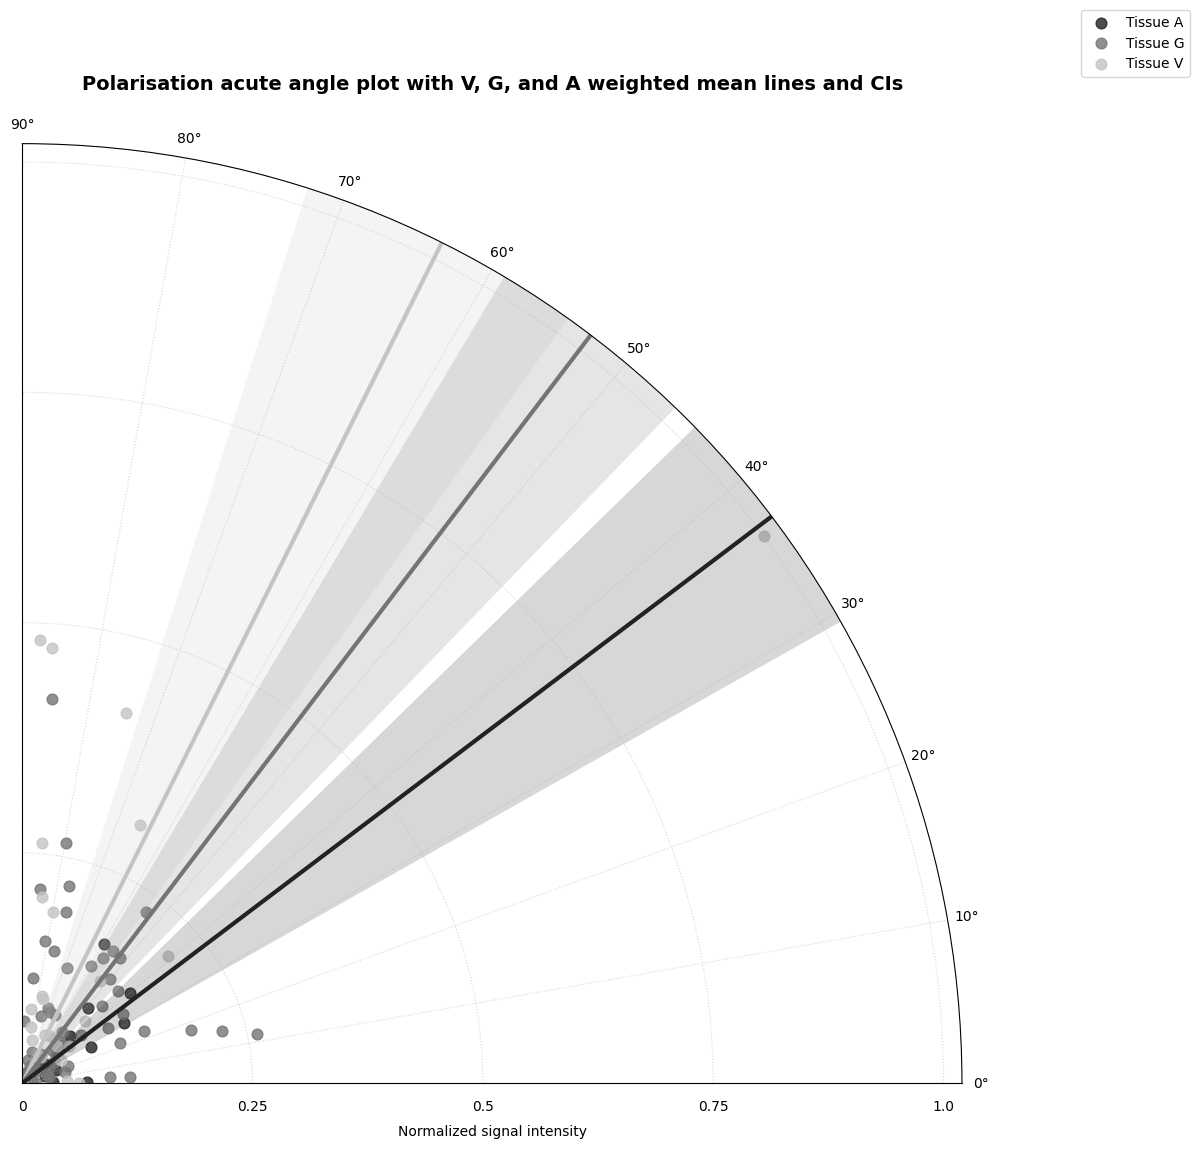

In [6]:
# Overlay main tissue weighted mean acute angles and CIs on the polarisation polar plot
fig2 = plt.figure(figsize=(12, 12))
ax2 = fig2.add_subplot(111, projection='polar')

# Plot all data points again for reference
for tissue, group in polar_df.groupby('Tissue'):
    ax2.scatter(group['theta'], group['r'], c=colors[tissue], label=f"Tissue {tissue}", alpha=0.8, s=60)

# Overlay weighted mean lines for main tissues V, G, and A using the already-computed weighted_means
r_max = 1.02
for tissue in ['V', 'G', 'A']:
    if 'weighted_means' in globals() and tissue in weighted_means['Tissue'].values:
        mean_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'mean_acute_angle'].iloc[0])
        lo_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_lo'].iloc[0])
        hi_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_hi'].iloc[0])
    else:
        mean_angle, lo_angle, hi_angle = get_weighted_stats(polar_df[polar_df['Tissue'] == tissue])

    theta_mean = np.radians(mean_angle)
    theta_lo = np.radians(lo_angle)
    theta_hi = np.radians(hi_angle)
    line_color = colors.get(tissue, '#000000')

    # Draw CI as a sector wedge anchored at the origin using ax.bar (avoids gaps)
    width = theta_hi - theta_lo
    if width < 0:
        width += 2 * np.pi
    ax2.bar((theta_lo + width/2), r_max, width=width, bottom=0.0,
            color=line_color, alpha=0.18, edgecolor='none', align='center')

    # Draw mean line on top
    ax2.plot([theta_mean, theta_mean], [0, r_max], color=line_color, linewidth=3, solid_capstyle='butt')

# Configure polar plot display
ax2.set_thetamin(0)
ax2.set_thetamax(90)
ax2.set_theta_zero_location("E")
ax2.set_theta_direction(1)
ax2.set_ylim(0, r_max)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
ax2.tick_params(axis='y', pad=8)
ax2.set_xlabel('Normalized signal intensity', labelpad=25)
plt.title("Polarisation acute angle plot with V, G, and A weighted mean lines and CIs", fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
ax2.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('polarisation_polar_plot_with_mean_lines.svg', format='svg')
print('Polar plot with main tissue weighted mean lines saved successfully.')


In [ ]:
# Combined polar plots for SOK1, SOK2, and SOK5
from pathlib import Path
sok_base = Path(r"E:\Work\\SOKs\\TIFFS_publication\\Fig SX_emergence-cellular\\polarisation\\script")
sok_list = ['SOK1', 'SOK2', 'SOK5']
# Minimal color palette (matches earlier cells)
colors = {'A': '#222222', 'G': '#747474', 'V': '#c4c4c4', 'CE': '#999999', 'E': '#bdbdbd'}

fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})
for ax, sok in zip(axs, sok_list):
    csv_folder = sok_base / sok
    polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
    if len(polarisation_files) == 0:
        print(f"No polarisation CSVs in {csv_folder}")
        ax.set_visible(False)
        continue

    polar_df = pd.concat((pd.read_csv(f) for f in polarisation_files), ignore_index=True)
    polar_df = polar_df[polar_df['Tissue'].isin(['A', 'G', 'V', 'CE'])].copy()
    polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['yMax']), np.abs(polar_df['xMax'])))
    polar_df['theta'] = np.radians(polar_df['deviation_degrees'])
    polar_df['r'] = polar_df['signalMax'] / polar_df['signalMax'].max()

    # Plot all data points
    for tissue, group in polar_df.groupby('Tissue'):
        ax.scatter(group['theta'], group['r'], c=colors.get(tissue, '#000000'), label=f"Tissue {tissue}", alpha=0.8, s=40)

    # Compute weighted means and bootstrap CIs using existing helper
    weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['signalMax'])).reset_index(name='mean_acute_angle')
    cis_local = {}
    for tissue, group in polar_df.groupby('Tissue'):
        mean, lo, hi = get_weighted_stats(group, n_boot=2000)
        cis_local[tissue] = (lo, hi)
    weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis_local[t][0])
    weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis_local[t][1])

    # Overlay weighted mean lines for V, G, A
    r_max = 1.02
    for tissue in ['V', 'G', 'A']:
        if tissue in weighted_means['Tissue'].values:
            mean_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'mean_acute_angle'].iloc[0])
            lo_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_lo'].iloc[0])
            hi_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_hi'].iloc[0])
        else:
            mean_angle, lo_angle, hi_angle = get_weighted_stats(polar_df[polar_df['Tissue'] == tissue], n_boot=2000)

        theta_mean = np.radians(mean_angle)
        theta_lo = np.radians(lo_angle)
        theta_hi = np.radians(hi_angle)
        line_color = colors.get(tissue, '#000000')

        width = theta_hi - theta_lo
        if width < 0:
            width += 2 * np.pi
        ax.bar((theta_lo + width/2), r_max, width=width, bottom=0.0,
               color=line_color, alpha=0.18, edgecolor='none', align='center')

        ax.plot([theta_mean, theta_mean], [0, r_max], color=line_color, linewidth=3, solid_capstyle='butt')

    # Configure polar plot display
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_ylim(0, r_max)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
    ax.tick_params(axis='y', pad=8)
    ax.set_xlabel('Normalized signal intensity', labelpad=15)
    ax.set_title(f"{sok} — Polarisation acute angle with weighted means", fontsize=12)
    if ax is axs[0]:
        ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
out = sok_base / 'polarisation_combined_SOK1_SOK2_SOK5.svg'
plt.savefig(out, format='svg')
print(f"Saved combined polar plot to {out}")
